In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_hist = "D://Niharika Work//Climate_Project//CMIP6//MPI-ESM1-2-LR_historical//"

In [3]:
rsdt_hist = xr.open_mfdataset(path_hist + "rsdt*.nc", use_cftime=True)['rsdt']
rsut_hist = xr.open_mfdataset(path_hist + "rsut*.nc", use_cftime=True)['rsut']
rlut_hist = xr.open_mfdataset(path_hist + "rlut*.nc", use_cftime=True)['rlut']

rsutcs_hist = xr.open_mfdataset(path_hist + "rsutcs*.nc", use_cftime=True)['rsutcs']
rlutcs_hist = xr.open_mfdataset(path_hist + "rlutcs*.nc", use_cftime=True)['rlutcs']

tas_hist = xr.open_mfdataset(path_hist + "tas*.nc", use_cftime=True)['tas']

C:\Users\shubh\AppData\Local\Temp\ipykernel_10052\1707478031.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsdt_hist = xr.open_mfdataset(path_hist + "rsdt*.nc", use_cftime=True)['rsdt']
C:\Users\shubh\AppData\Local\Temp\ipykernel_10052\1707478031.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsdt_hist = xr.open_mfdataset(path_hist + "rsdt*.nc", use_cftime=True)['rsdt']
C:\Users\shubh\AppData\Local\Temp\ipykernel_10052\1707478031.py:1: DeprecationWarning: Usage of 'use

In [4]:
rsdt_hist = rsdt_hist.sel(time=slice("2001","2014"))
rsut_hist = rsut_hist.sel(time=slice("2001","2014"))
rlut_hist = rlut_hist.sel(time=slice("2001","2014"))

rsutcs_hist = rsutcs_hist.sel(time=slice("2001","2014"))
rlutcs_hist = rlutcs_hist.sel(time=slice("2001","2014"))

tas_hist = tas_hist.sel(time=slice("2001","2014"))

In [5]:
toa_net_hist = rsdt_hist - rsut_hist - rlut_hist        # Net=rsdt−rsut−rlut

In [6]:
sw_cre_hist = rsutcs_hist - rsut_hist       # SWcre=rsutcs−rsut
lw_cre_hist = rlutcs_hist - rlut_hist       # LWcre=rlutcs−rlut

net_cre_hist = sw_cre_hist + lw_cre_hist

In [7]:
# Grid cells shrink toward the poles, so we weight by cos(latitude).

weights = np.cos(np.deg2rad(net_cre_hist.lat))
weights.name = "weights"

In [8]:
cre_hist_global = net_cre_hist.weighted(weights).mean(("lat","lon"))

In [9]:
cre_hist_mean = cre_hist_global.mean("time")
print(cre_hist_mean.values)

-23.57693849515222


In [10]:
# weights = np.cos(np.deg2rad(tas_hist.lat))
# weights.name = "weights"

T_global = tas_hist.weighted(weights).mean(("lat","lon"))

In [11]:
toa_net_hist = rsdt_hist - rsut_hist - rlut_hist        # R=rsdt−rsut−rlut

R_global = toa_net_hist.weighted(weights).mean(("lat","lon"))

In [12]:
# T_anom = T_global - T_global.mean("time")
# R_anom = R_global - R_global.mean("time")

T_anom = T_global.groupby("time.month") - T_global.groupby("time.month").mean()

R_anom = R_global.groupby("time.month") - R_global.groupby("time.month").mean()

In [13]:
print(R_anom.min(), R_anom.max())

<xarray.DataArray ()> Size: 8B
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray> <xarray.DataArray ()> Size: 8B
dask.array<_nanmax_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>


In [14]:
# Convert to NumPy Arrays
# Regression needs numpy arrays.

T_anom_np = T_anom.values
R_anom_np = R_anom.values

In [15]:
# lambda_feedback = np.polyfit(T_anom_np, R_anom_np, 1)[0]

# Before regression, remove NaN values:
mask = np.isfinite(T_anom_np) & np.isfinite(R_anom_np)

lambda_feedback = np.polyfit(
    T_anom_np[mask],
    R_anom_np[mask],
    1
)[0]

print("Feedback parameter λ =", lambda_feedback, "W m^-2 K^-1")

Feedback parameter λ = -1.151372775094319 W m^-2 K^-1


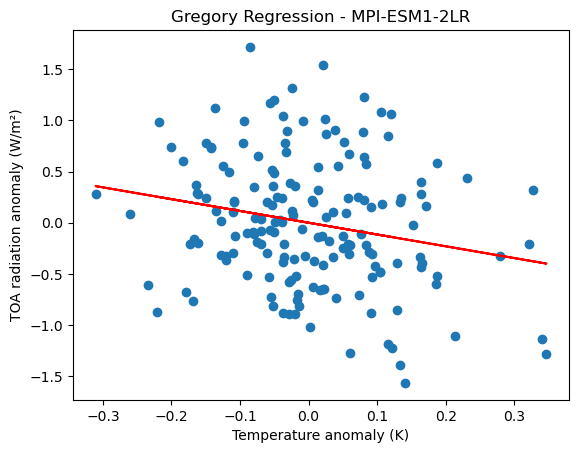

In [26]:
import matplotlib.pyplot as plt

plt.scatter(T_anom_np, R_anom_np)

fit = np.polyfit(T_anom_np, R_anom_np, 1)
plt.plot(T_anom_np, fit[0]*T_anom_np + fit[1], color="red")

plt.xlabel("Temperature anomaly (K)")
plt.ylabel("TOA radiation anomaly (W/m²)")
plt.title("Gregory Regression - MPI-ESM1-2LR")

plt.show()

# Compare CMIP6 model radiation with CERES satellite observations

In [17]:
path_ceres = "D://Niharika Work//Climate_Project//CERES_EBAF-TOA_Edition4.1-20260303_075023//"

ceres = xr.open_dataset(path_ceres + "CERES_EBAF-TOA_Edition4.1_200003-202203.nc")

print(ceres)

<xarray.Dataset> Size: 792MB
Dimensions:                        (lon: 360, lat: 180, ctime: 12, sc: 2,
                                    time: 265)
Coordinates:
  * lon                            (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                            (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * ctime                          (ctime) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * time                           (time) datetime64[ns] 2kB 2000-03-15 ... 2...
Dimensions without coordinates: sc
Data variables: (12/67)
    climatology_bounds             (ctime, sc) int32 96B ...
    toa_sw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_lw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_net_all_mon                (time, lat, lon) float32 69MB ...
    toa_sw_clr_c_mon               (time, lat, lon) float32 69MB ...
    toa_lw_clr_c_mon               (time, lat, lon) float32 69MB ...
    ...                             ...
    gtoa_n

In [18]:
ceres = ceres.sel(time=slice("2001","2014"))

In [19]:
ceres_sw = ceres['toa_sw_all_mon']
ceres_lw = ceres['toa_lw_all_mon']
ceres_net = ceres['toa_net_all_mon']

In [20]:
# CERES grid is 1°×1°, but we still weight properly.
weights_ceres = np.cos(np.deg2rad(ceres.lat))

ceres_net_global = ceres_net.weighted(weights_ceres).mean(("lat","lon"))

In [21]:
model_net_global = toa_net_hist.weighted(weights).mean(("lat","lon"))

In [22]:
model_net_global["time"] = model_net_global.indexes["time"].to_datetimeindex()

C:\Users\shubh\AppData\Local\Temp\ipykernel_10052\806988269.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  model_net_global["time"] = model_net_global.indexes["time"].to_datetimeindex()


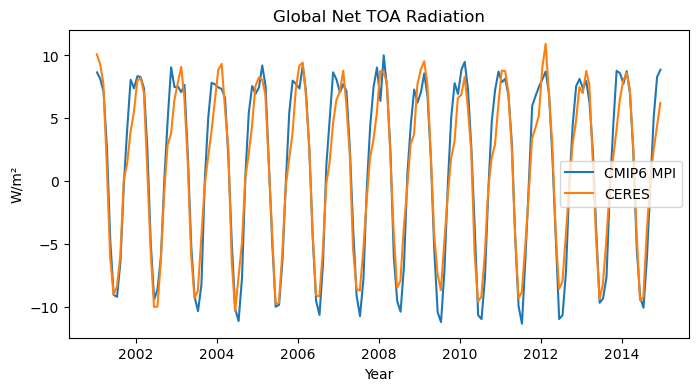

In [25]:
plt.figure(figsize=(8,4))

model_net_global.plot(label="CMIP6 MPI")
ceres_net_global.plot(label="CERES")

plt.xlabel("Year")

plt.legend()
plt.title("Global Net TOA Radiation")
plt.ylabel("W/m²")

plt.show()